# EDA & DAG Validation
- Research question: How SME composition, economic resilience, and employment shape local labour productivity in Swindon.

- Causal chain (DAG): Policy -> Business Size Structure -> Economic Resilience -> Employment Rate -> GVA.

- This is an explanatory study: features are chosen by the DAG nodes, not by an algorithm. A full-feature model and SHAP are used only to confirm the DAG variables carry the signal, and path analysis quantifies each arrow.

- Target is log GVA per worker (labour productivity)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
short = lambda c: c[:32]
target = "log_gva_per_worker"
def winsorize(frame, cols, bounds=None, lo=0.01, hi=0.99):
    out = frame.copy()
    if bounds is None:
        bounds = {c: (out[c].quantile(lo), out[c].quantile(hi)) for c in cols}
    for c in cols:
        out[c] = out[c].clip(*bounds[c])
    return out, bounds
# explanatory analysis uses the full, unscaled engineered table
df = pd.read_csv("4-features_engineered.csv")
df["is_swindon"] = np.where(
    df["LSOA21NM"].str.replace(r"\s\d.*", "", regex=True).eq("Swindon"),
    "Swindon", "Others")
num_feats = df.select_dtypes("number").columns.tolist()
df, _ = winsorize(df, num_feats)

## 1. Bivariate analysis - validate the causal chain step by step

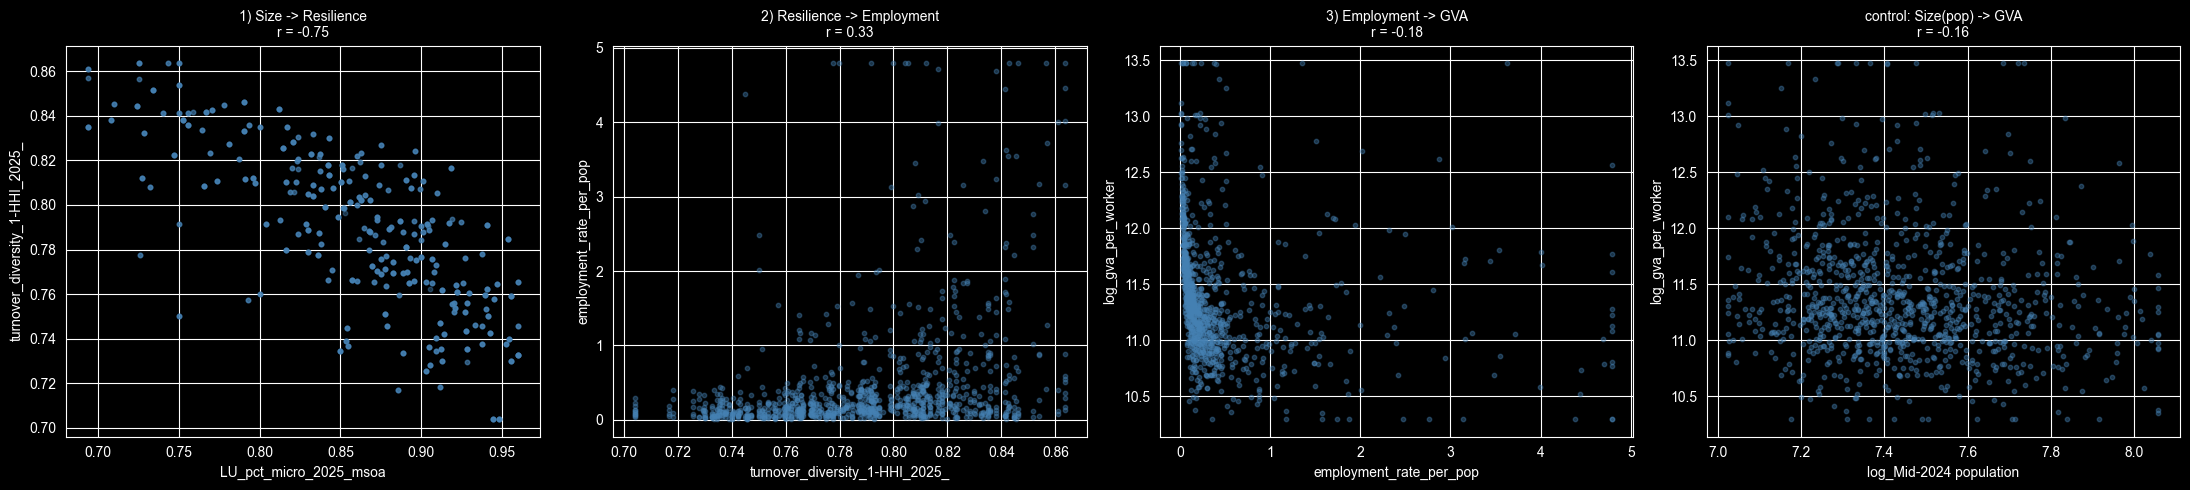

In [2]:
steps = [
    ("LU_pct_micro_2025_msoa", "turnover_diversity_1-HHI_2025_msoa", "1) Size -> Resilience"),
    ("turnover_diversity_1-HHI_2025_msoa", "employment_rate_per_pop", "2) Resilience -> Employment"),
    ("employment_rate_per_pop", target, "3) Employment -> GVA"),
    ("log_Mid-2024 population", target, "control: Size(pop) -> GVA"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (x, y, title) in zip(axes, steps):
    ax.scatter(df[x], df[y], s=10, alpha=0.4, color="steelblue")
    ax.set_xlabel(x[:30]); ax.set_ylabel(y[:30])
    ax.set_title(f"{title}\nr = {df[x].corr(df[y]):.2f}", fontsize=10)
plt.tight_layout()
plt.show()

## 2. Collinearity check

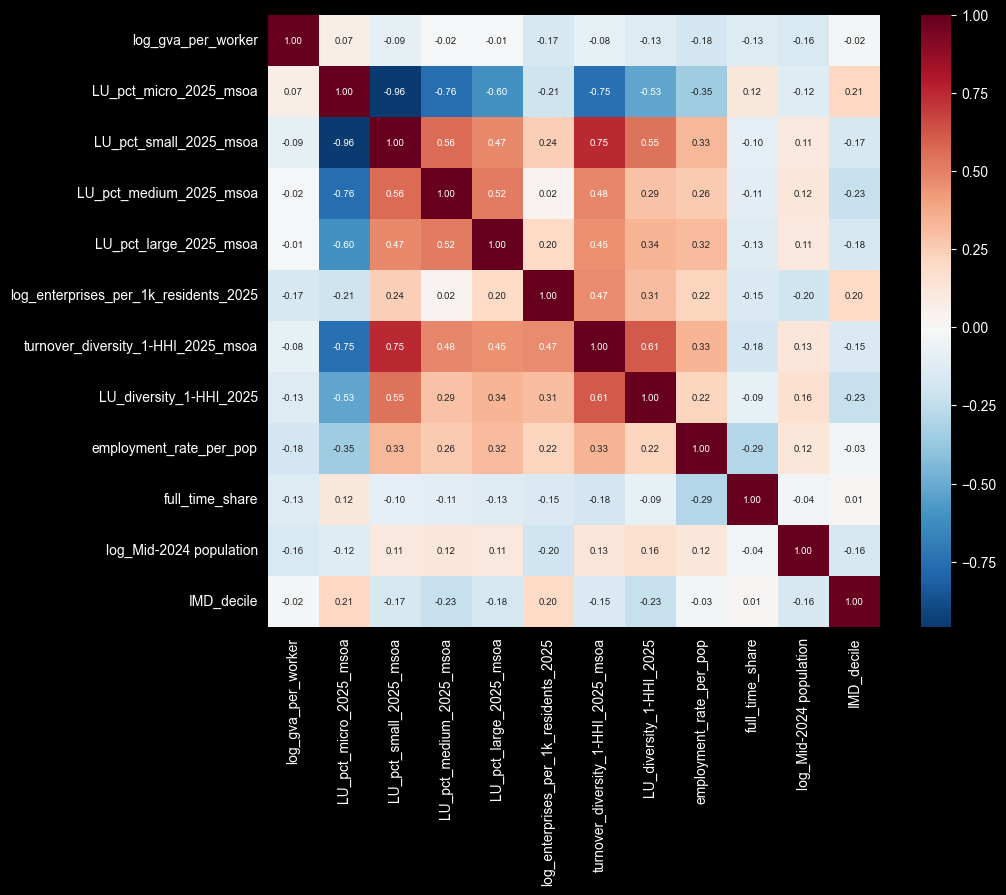

In [3]:
node_vars = [
    target,
    "LU_pct_micro_2025_msoa", "LU_pct_small_2025_msoa",
    "LU_pct_medium_2025_msoa", "LU_pct_large_2025_msoa",
    "log_enterprises_per_1k_residents_2025",
    "turnover_diversity_1-HHI_2025_msoa", "LU_diversity_1-HHI_2025",
    "employment_rate_per_pop", "full_time_share",
    "log_Mid-2024 population", "IMD_decile",
]
corr = df[node_vars].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, annot_kws={"size": 7})
plt.tight_layout()
plt.show()

## 3. Group comparison (urban/rural and Swindon vs others)

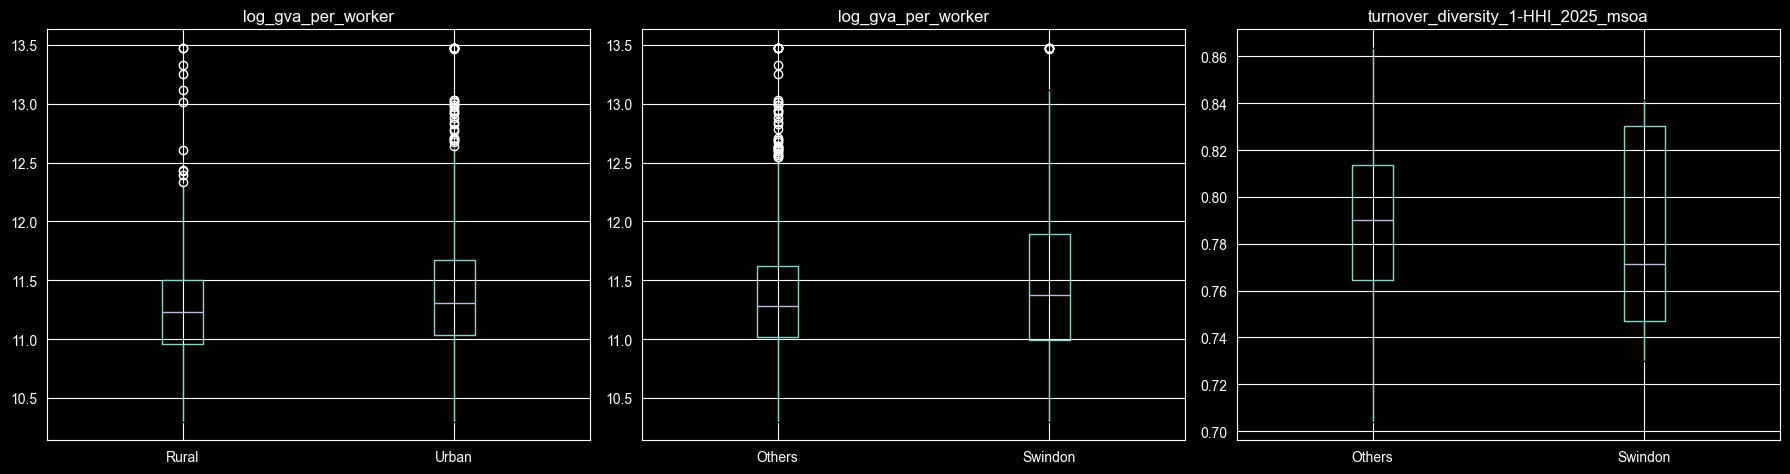

is_swindon                                    Others    Swindon
log_gva_per_worker                 mean    11.368552  11.504171
                                   median  11.278291  11.373387
gva_per_capita                     mean     0.040183   0.041756
                                   median   0.014446   0.009522
LU_pct_micro_2025_msoa             mean     0.861131   0.850491
                                   median   0.868421   0.877358
turnover_diversity_1-HHI_2025_msoa mean     0.789067   0.784954
                                   median   0.790001   0.771358
employment_rate_per_pop            mean     0.461268   0.455743
                                   median   0.204213   0.133601
full_time_share                    mean     0.343340   0.373757
                                   median   0.333333   0.375000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df.boxplot(column=target, by="Urban_rura", ax=axes[0])
df.boxplot(column=target, by="is_swindon", ax=axes[1])
df.boxplot(column="turnover_diversity_1-HHI_2025_msoa", by="is_swindon", ax=axes[2])
for ax in axes:
    ax.set_xlabel(""); plt.suptitle("")
plt.tight_layout()
plt.show()

print(df.groupby("is_swindon")[[
    target, "gva_per_capita", "LU_pct_micro_2025_msoa",
    "turnover_diversity_1-HHI_2025_msoa", "employment_rate_per_pop", "full_time_share",
]].agg(["mean", "median"]).T)

## 4. Spatial analysis (map + spatial clustering)

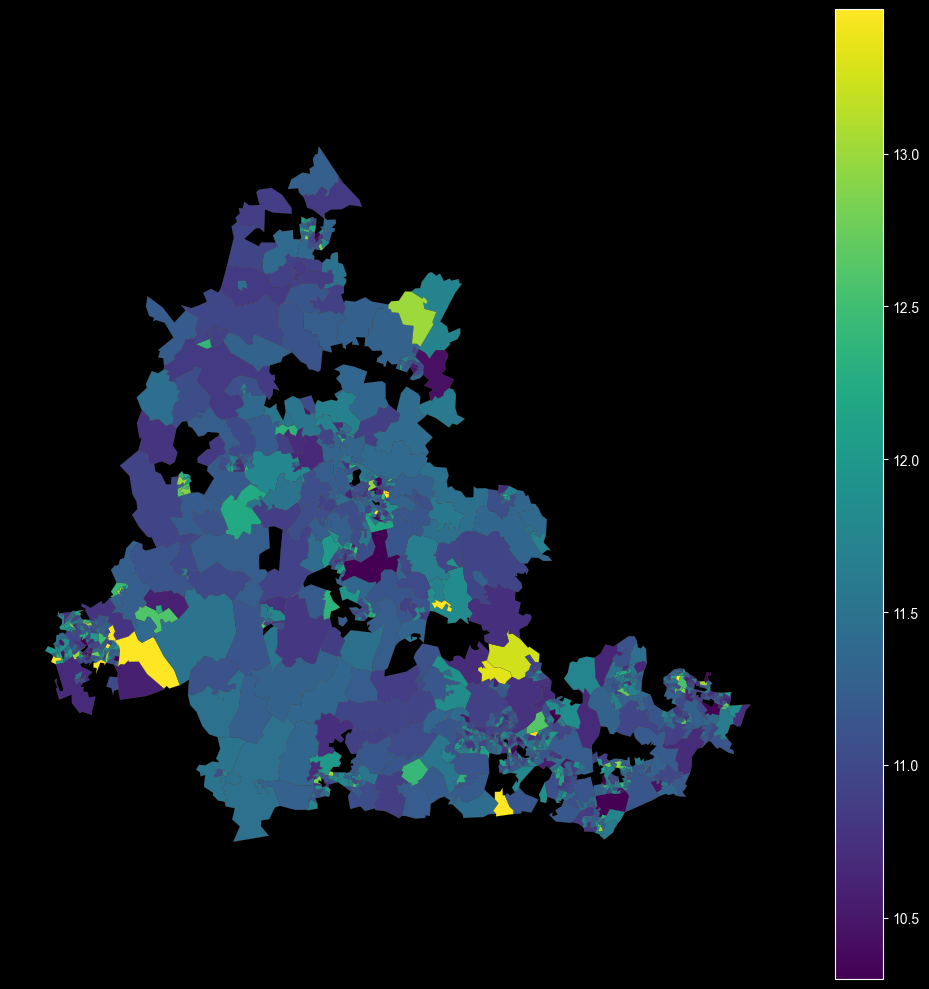

In [5]:
import geopandas as gpd
gdf = gpd.read_file("LSOA_boundaries.geojson").merge(df, on="LSOA21CD")
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column=target, cmap="viridis", legend=True, ax=ax, linewidth=0.1, edgecolor="grey")
ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
from libpysal.weights import KNN
from esda.moran import Moran
g = gdf.dropna(subset=[target]).reset_index(drop=True)
w = KNN.from_dataframe(g, k=6); w.transform = "r"
mi = Moran(g[target], w)
print("Moran's I (KNN):", round(mi.I, 3), "p:", round(mi.p_sim, 3))

Moran's I (KNN): 0.089 p: 0.001


D:\MYAPP\python3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5. Theory-driven feature set

In [7]:
dag = {
    "Policy proxy":     ["Urban_rura"],
    "Business size":    ["LU_pct_micro_2025_msoa", "LU_pct_large_2025_msoa",
                         "log_enterprises_per_1k_residents_2025"],
    "Econ resilience":  ["turnover_diversity_1-HHI_2025_msoa"],
    "Employment":       ["employment_rate_per_pop", "full_time_share"],
    "Size control":     ["log_Mid-2024 population"],
    "Deprivation ctrl": ["IMD_decile"],
}
for node, cols in dag.items():
    print(f"{node:18s}: {cols}")
dag_num = [c for cols in dag.values() for c in cols if c != "Urban_rura"]
print(f"{len(dag_num) + 1} features total ({len(dag_num)} numeric + Urban_rura)")

Policy proxy      : ['Urban_rura']
Business size     : ['LU_pct_micro_2025_msoa', 'LU_pct_large_2025_msoa', 'log_enterprises_per_1k_residents_2025']
Econ resilience   : ['turnover_diversity_1-HHI_2025_msoa']
Employment        : ['employment_rate_per_pop', 'full_time_share']
Size control      : ['log_Mid-2024 population']
Deprivation ctrl  : ['IMD_decile']
9 features total (8 numeric + Urban_rura)


### 5.1 Within-node redundancy - VIF on the DAG numeric features

In [8]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xv = sm.add_constant(df[dag_num].dropna())
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
                index=Xv.columns).drop("const").sort_values(ascending=False)
print(vif.round(2))
print("All VIF < 10:", bool((vif < 10).all()))

turnover_diversity_1-HHI_2025_msoa       3.15
LU_pct_micro_2025_msoa                   3.13
log_enterprises_per_1k_residents_2025    1.66
LU_pct_large_2025_msoa                   1.64
employment_rate_per_pop                  1.29
IMD_decile                               1.16
log_Mid-2024 population                  1.14
full_time_share                          1.11
dtype: float64
All VIF < 10: True


## 6. Distributions of the selected features

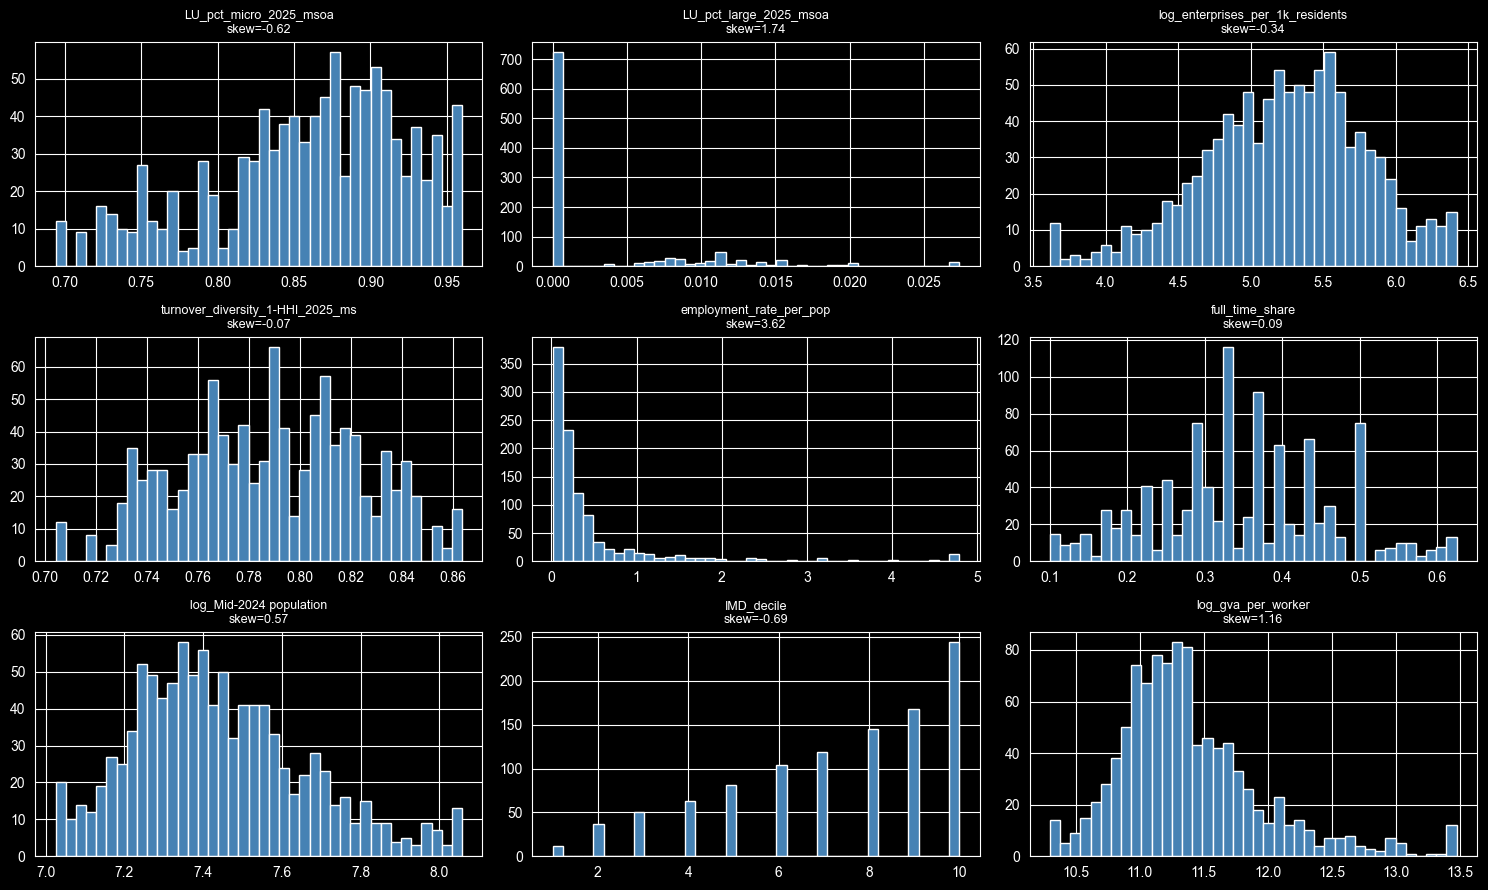

In [9]:
key = dag_num + [target]
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, c in zip(axes.flat, key):
    df[c].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{short(c)}\nskew={df[c].skew():.2f}", fontsize=9)
for ax in axes.flat[len(key):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

<cell_type>markdown</cell_type>## 7. Cross-validate the DAG — A (size) vs B (efficiency)
Same DAG features, two targets: **A = total GVA** (economic *size*) and **B = GVA per worker** (labour *efficiency / productivity*). The contrast is the finding — structural variables explain size almost fully (R²≈0.75) but explain little of efficiency (R²≈0.18).

In [14]:
from sklearn.ensemble import RandomForestRegressor
train = pd.read_csv("6-train_encoded.csv")
test  = pd.read_csv("6-test_encoded.csv")
for d_ in (train, test):
    d_["is_swindon"] = d_["LSOA21NM"].str.replace(r"\s\d.*", "", regex=True).eq("Swindon").astype(int)

leak = ["LSOA GVA Estimates (millions)", "log_LSOA GVA Estimates (millions)",
        "gva_per_capita", "log_gva_per_capita",
        "gva_per_worker", "log_gva_per_worker"]
ids  = ["LSOA21CD", "LSOA21NM", "MSOA21CD", "MSOA21NM"]
raw_dupes = [c for c in train.columns if f"log_{c}" in train.columns]
full_cols = train.drop(columns=leak + ids + raw_dupes, errors="ignore").select_dtypes("number").columns.tolist()
dag_model_cols = [c for c in (["Urban_rura_Urban", "is_swindon"] + dag_num) if c in train.columns]
# winsorize FEATURES once with train-derived bounds
train, wb = winsorize(train, full_cols)
test,  _  = winsorize(test,  full_cols, bounds=wb)

TARGETS = {"A: total GVA (size)":            "log_LSOA GVA Estimates (millions)",
           "B: GVA per worker (efficiency)": "log_gva_per_worker"}
rows, fitted = [], {}
for name, tcol in TARGETS.items():
    tr, tb = winsorize(train, [tcol]); te, _ = winsorize(test, [tcol], bounds=tb)
    m_dag  = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1).fit(tr[dag_model_cols], tr[tcol])
    m_full = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1).fit(tr[full_cols],      tr[tcol])
    r_dag, r_full = m_dag.score(te[dag_model_cols], te[tcol]), m_full.score(te[full_cols], te[tcol])
    rows.append({"target": name, "DAG R2": round(r_dag, 3), "Full R2": round(r_full, 3),
                 "DAG captures": f"{r_dag / r_full * 100:.0f}% of Full"})
    fitted[tcol] = (m_dag, m_full)
print(pd.DataFrame(rows).to_string(index=False))

rf, rf_full = fitted[target]
print(f"Top full-model features for {target}:")
imp = pd.Series(rf_full.feature_importances_, index=full_cols).sort_values(ascending=False).head(10)
for c, v in imp.items():
    tag = "DAG" if c in dag_model_cols else "non-DAG (scale/control)"
    print(f"  {v:6.3f}  [{tag:24s}] {short(c)}")

                        target  DAG R2  Full R2 DAG captures
           A: total GVA (size)   0.747    0.758  98% of Full
B: GVA per worker (efficiency)   0.177    0.205  86% of Full
Top full-model features for log_gva_per_worker:
   0.220  [DAG                     ] employment_rate_per_pop
   0.082  [non-DAG (scale/control) ] log_full_time_employees
   0.057  [non-DAG (scale/control) ] log_total_employees
   0.031  [non-DAG (scale/control) ] Apprenticeship %
   0.031  [non-DAG (scale/control) ] Level 3 qualifications: 2 or mor
   0.029  [non-DAG (scale/control) ] log_part_time_employees
   0.027  [non-DAG (scale/control) ] log_employees_per_enterprise
   0.025  [non-DAG (scale/control) ] log_area_km2
   0.024  [non-DAG (scale/control) ] Other: vocational or work-relate
   0.022  [non-DAG (scale/control) ] log_dist_to_primary_m


### 7.1 SHAP attribution of the DAG model

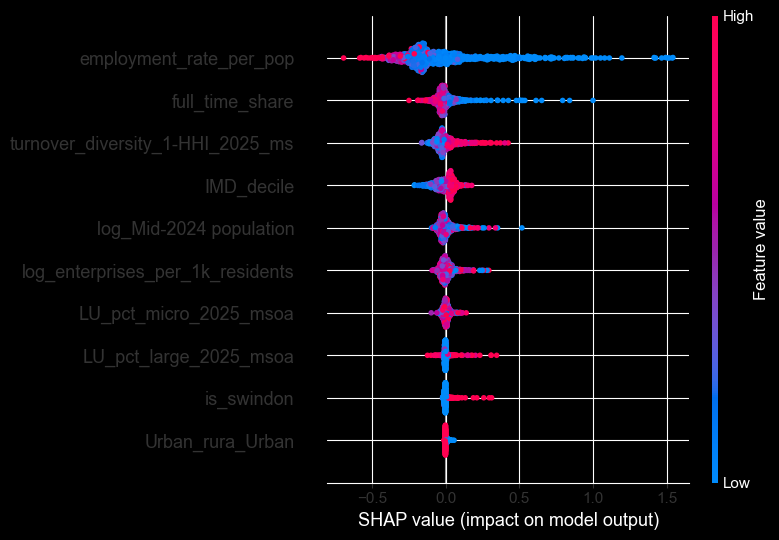

employment_rate_per_pop             0.244
full_time_share                     0.051
turnover_diversity_1-HHI_2025_ms    0.047
IMD_decile                          0.045
log_Mid-2024 population             0.033
log_enterprises_per_1k_residents    0.029
LU_pct_micro_2025_msoa              0.015
LU_pct_large_2025_msoa              0.011
is_swindon                          0.009
Urban_rura_Urban                    0.005
dtype: float64


In [11]:
import shap
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(train[dag_model_cols])
shap.summary_plot(sv, train[dag_model_cols], feature_names=[short(c) for c in dag_model_cols], show=True)
shap_imp = pd.Series(np.abs(sv).mean(0), index=dag_model_cols).sort_values(ascending=False)
print(shap_imp.round(3).rename(short))

## 8. Path analysis

In [18]:
import statsmodels.formula.api as smf
from IPython.display import display

z = lambda s: (s - s.mean()) / s.std()
TARGETS = {"A: total GVA (size)": "log_LSOA GVA Estimates (millions)",
           "B: GVA per worker (efficiency)": "log_gva_per_worker"}

def build_P(frame, tcol):
    return pd.DataFrame({
        "size":       z(frame["LU_pct_micro_2025_msoa"]),
        "resilience": z(frame["turnover_diversity_1-HHI_2025_msoa"]),
        "employment": z(frame["employment_rate_per_pop"]),
        "gva":        z(frame[tcol]),
        "urban":      (frame["Urban_rura"] == "Urban").astype(int),
        "logpop":     z(frame["log_Mid-2024 population"]),
        "imd":        z(frame["IMD_decile"]),
        "swindon":    frame["is_swindon"].eq("Swindon").astype(int),
        "msoa":       frame["MSOA21CD"].values,
    }, index=frame.index).dropna()

def run_paths(P, label, controls, cluster=True):
    ctrl = [c for c in controls if P[c].nunique() > 1]
    rhs = " + ".join(ctrl)
    def fit(formula):
        m = smf.ols(formula, P)
        return (m.fit(cov_type="cluster", cov_kwds={"groups": P["msoa"]})
                if cluster else m.fit(cov_type="HC3"))
    m1 = fit(f"resilience ~ size + {rhs}")
    m2 = fit(f"employment ~ resilience + size + {rhs}")
    m3 = fit(f"gva ~ employment + resilience + size + {rhs}")
    paths = pd.DataFrame({
        "arrow": ["size -> resilience", "resilience -> employment", "employment -> gva",
                  "resilience -> gva (direct)", "size -> gva (direct)"],
        "beta":  [m1.params["size"], m2.params["resilience"], m3.params["employment"],
                  m3.params["resilience"], m3.params["size"]],
        "p":     [m1.pvalues["size"], m2.pvalues["resilience"], m3.pvalues["employment"],
                  m3.pvalues["resilience"], m3.pvalues["size"]],
    })
    paths["sig"] = pd.cut(paths["p"], [-1, .001, .01, .05, 1], labels=["***", "**", "*", "ns"])
    paths["beta"] = paths["beta"].round(3); paths["p"] = paths["p"].round(3)
    se = f"cluster({P['msoa'].nunique()})" if cluster else f"HC3({P['msoa'].nunique()})"
    cap = f"{label} | SE {se} | GVA-eq R2={m3.rsquared:.3f} | n={int(m3.nobs)}"
    display(paths.style.set_caption(cap))
    return m1, m2, m3

contrast = []
for name, tcol in TARGETS.items():
    m1, m2, m3 = run_paths(build_P(df, tcol), name + " - ALL REGIONS",
                           ["urban", "logpop", "imd", "swindon"], cluster=True)
    contrast.append({"target": name,
                     "size->resil": round(m1.params["size"], 3),
                     "resil->emp":  round(m2.params["resilience"], 3),
                     "emp->GVA":    round(m3.params["employment"], 3),
                     "emp->GVA p":  round(m3.pvalues["employment"], 3),
                     "GVA-eq R2":   round(m3.rsquared, 3)})

display(pd.DataFrame(contrast).style.set_caption("A vs B contrast").hide(axis="index"))
run_paths(build_P(df[df["is_swindon"].eq("Swindon")], TARGETS["B: GVA per worker (efficiency)"]),
          "B SWINDON ONLY (robustness)", ["urban", "logpop", "imd"], cluster=False)

,arrow,beta,p,sig
0,size -> resilience,-0.756000,0.000000,***
1,resilience -> employment,0.134000,0.001000,**
2,employment -> gva,0.663000,0.000000,***
3,resilience -> gva (direct),0.151000,0.000000,***
4,size -> gva (direct),-0.008000,0.840000,ns


,arrow,beta,p,sig
0,size -> resilience,-0.756000,0.000000,***
1,resilience -> employment,0.134000,0.001000,**
2,employment -> gva,-0.159000,0.000000,***
3,resilience -> gva (direct),0.026000,0.664000,ns
4,size -> gva (direct),0.033000,0.607000,ns


target,size->resil,resil->emp,emp->GVA,emp->GVA p,GVA-eq R2
A: total GVA (size),-0.756000,0.134000,0.663000,0.000000,0.641000
B: GVA per worker (efficiency),-0.756000,0.134000,-0.159000,0.000000,0.064000


,arrow,beta,p,sig
0,size -> resilience,-0.911000,0.000000,***
1,resilience -> employment,0.246000,0.273000,ns
2,employment -> gva,-0.133000,0.361000,ns
3,resilience -> gva (direct),0.596000,0.011000,*
4,size -> gva (direct),0.679000,0.002000,**


(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x244dadb9d30>,
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x244ed7795e0>)

### 8.1 Save the theory-driven feature set

In [17]:
both_targets = ["log_LSOA GVA Estimates (millions)", "log_gva_per_worker"]
for t in both_targets:
    if t in train.columns:
        train, tb = winsorize(train, [t]); test, _ = winsorize(test, [t], bounds=tb)
keep_meta = [c for c in (["LSOA21CD", "LSOA21NM", "MSOA21CD", "MSOA21NM"] + both_targets) if c in train.columns]
cols = keep_meta + dag_model_cols
train[cols].to_csv("7-train_final.csv", index=False)
test[cols].to_csv("7-test_final.csv", index=False)
print(dag_model_cols)

['Urban_rura_Urban', 'is_swindon', 'LU_pct_micro_2025_msoa', 'LU_pct_large_2025_msoa', 'log_enterprises_per_1k_residents_2025', 'turnover_diversity_1-HHI_2025_msoa', 'employment_rate_per_pop', 'full_time_share', 'log_Mid-2024 population', 'IMD_decile']
